# 01 — Data Exploration

**Goal:** Understand what the raw Yelp dataset looks like before touching any NLP.

Questions to answer:
- What files are in the dataset and what are their schemas?
- What is the distribution of review text lengths?
- What is the star rating distribution?
- What date range do the reviews cover?
- Are there obvious quality issues (empty reviews, duplicates, non-English)?

**Output:** A fixed sample of N reviews saved to `data/cache/sample_5k.jsonl` for use in all downstream notebooks.

In [4]:
import json
import tarfile
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('../data/raw/Yelp-JSON/Yelp JSON')
CACHE_DIR = Path('../data/cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

TAR_PATH = DATA_DIR / 'yelp_dataset.tar'
print(f'Tar exists: {TAR_PATH.exists()}, size: {TAR_PATH.stat().st_size / 1e9:.1f} GB')

Tar exists: True, size: 4.3 GB


In [5]:
# List files in the tar without extracting everything
with tarfile.open(TAR_PATH) as tar:
    members = tar.getmembers()
    for m in members:
        print(f'{m.name:60s} {m.size / 1e6:8.1f} MB')

Dataset_User_Agreement.pdf                                        0.1 MB
yelp_academic_dataset_business.json                             118.9 MB
yelp_academic_dataset_checkin.json                              287.0 MB
yelp_academic_dataset_review.json                              5341.9 MB
yelp_academic_dataset_tip.json                                  180.6 MB
yelp_academic_dataset_user.json                                3363.3 MB


In [6]:
# Stream reviews from the tar — no full extraction needed
SAMPLE_SIZE = 5_000
SAMPLE_PATH = CACHE_DIR / 'sample_5k.jsonl'

if SAMPLE_PATH.exists():
    print('Sample already exists, loading from cache.')
    reviews = [json.loads(l) for l in SAMPLE_PATH.read_text().splitlines()]
else:
    reviews = []
    with tarfile.open(TAR_PATH) as tar:
        review_member = next(m for m in tar.getmembers() if 'review' in m.name.lower())
        f = tar.extractfile(review_member)
        for line in f:
            reviews.append(json.loads(line))
            if len(reviews) >= SAMPLE_SIZE:
                break
    with open(SAMPLE_PATH, 'w') as out:
        for r in reviews:
            out.write(json.dumps(r) + '\n')
    print(f'Saved {len(reviews)} reviews to {SAMPLE_PATH}')

df = pd.DataFrame(reviews)
print(df.dtypes)
df.head(3)

Sample already exists, loading from cache.
review_id          str
user_id            str
business_id        str
stars          float64
useful           int64
funny            int64
cool             int64
text               str
date               str
dtype: object


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30


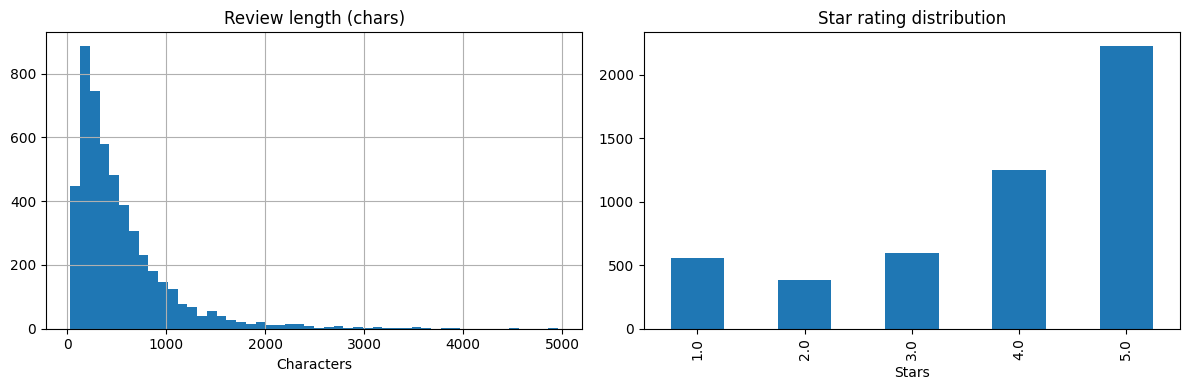

count    5000.000000
mean      545.053200
std       491.097035
min        33.000000
25%       221.000000
50%       399.000000
75%       695.250000
max      4959.000000
Name: text_len, dtype: float64


In [7]:
# Text length distribution
df['text_len'] = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['text_len'].hist(bins=50, ax=axes[0])
axes[0].set_title('Review length (chars)')
axes[0].set_xlabel('Characters')

df['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Star rating distribution')
axes[1].set_xlabel('Stars')

plt.tight_layout()
plt.show()

print(df['text_len'].describe())

Date range: 2005-03-12 03:47:06 → 2018-10-04 18:10:01


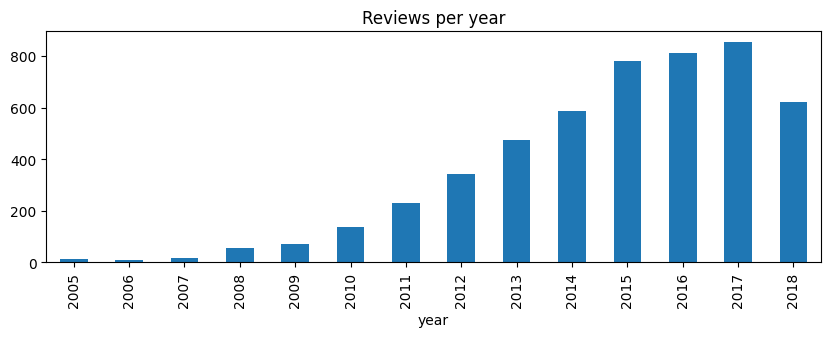

In [8]:
# Date range
df['date'] = pd.to_datetime(df['date'])
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
df['year'] = df['date'].dt.year
df['year'].value_counts().sort_index().plot(kind='bar', figsize=(10, 3), title='Reviews per year')
plt.show()

In [9]:
# Quality checks
print('Empty text:', df['text'].isna().sum() + (df['text'].str.strip() == '').sum())
print('Exact duplicates:', df['text'].duplicated().sum())
print('Very short (<20 chars):', (df['text_len'] < 20).sum())

# Sample of short reviews
df[df['text_len'] < 50][['stars', 'text']].head(5)

Empty text: 0
Exact duplicates: 0
Very short (<20 chars): 0


,stars,text
534,4.0,"Friendly staff, good selection, fair prices."
1190,3.0,Brooke's music needs to go. No more pop edm.
1374,3.0,Can't go wrong with some Todd Cobell!
2085,4.0,Great location and a great staff.
2091,4.0,"Mexican ""comfort"" food....love from a truck."


In [10]:
# Sample reviews per star rating
for stars in [1, 3, 5]:
    sample = df[df['stars'] == stars]['text'].iloc[0]
    print(f'--- {stars} stars ---')
    print(sample[:300])
    print()

--- 1 stars ---
I am a long term frequent customer of this establishment. I just went in to order take out (3 apps) and was told they're too busy to do it. Really? The place is maybe half full at best. Does your dick reach your ass? Yes? Go fuck yourself! I'm a frequent customer AND great tipper. Glad that Kanella 

--- 3 stars ---
If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. 

The food is good, but it takes a very long time to come out. The w

--- 5 stars ---
I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every class is a top notch work out.

For anyone who struggles to fit workouts in, the online scheduling syst

